# IMPORT

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score


# DATA LOAD
- 100bp
- threshold(cpg site) 4이상
- 블락 별 베타 벨류값 평균

In [ ]:
n=100
th=4

data = pd.read_csv(f'/ssd_data/Methylation/results/step02_DMR/{n}기준_{th}이상_평균_v1.csv')


In [ ]:
data


,1_105,1_8274,1_8700,1_9102,1_9103,1_9206,1_9237,1_9246,1_9405,1_9597,...,X_1558813,Y_113065,Y_113075,Y_113148,Y_113215,Y_113325,Y_113326,Y_113334,Y_113335,Type
0,1.000000,0.000000,0.033333,0.015942,0.000000,0.154762,0.000000,0.026087,0.009615,0.605263,...,0.166667,0.900000,0.645455,0.857143,0.850000,0.692857,0.507003,0.547222,0.548641,0.0
1,0.857143,0.000000,0.000000,0.058824,0.000000,0.384615,0.000000,0.000000,0.011765,0.303030,...,0.500000,0.800000,1.000000,0.772222,0.600000,0.480000,0.595098,0.439205,0.588848,0.0
2,0.833333,0.000000,0.000000,0.000000,0.041667,0.384615,0.000000,0.000000,0.000000,0.336538,...,0.483135,0.812500,0.960000,0.897959,0.750000,0.750000,0.592157,0.554985,0.461310,0.0
3,0.861111,0.000000,0.000000,0.000000,0.000000,0.428571,0.000000,0.017391,0.000000,0.600000,...,0.361111,0.937500,0.600000,0.500000,0.733333,0.533333,0.581232,0.366305,0.517476,0.0
4,0.785714,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.555556,0.785985,0.933333,0.750000,0.800000,0.562500,0.666667,0.602306,0.502723,0.0
5,0.857143,0.000000,0.000000,0.058824,0.000000,0.384615,0.000000,0.000000,0.011765,0.303030,...,0.500000,0.800000,1.000000,0.772222,0.600000,0.480000,0.595098,0.439205,0.588848,0.0
6,1.000000,0.000000,0.000000,0.022727,0.033333,0.062500,0.016667,0.000000,0.000000,0.250000,...,0.000000,0.816319,0.716667,0.893750,0.771429,0.650000,0.567647,0.478838,0.643275,0.0
7,1.000000,0.000000,0.083333,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000,0.666667,...,0.666667,0.700000,0.600000,0.638889,0.800000,0.640000,0.616667,0.392232,0.505847,0.0
8,0.666667,0.071429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.428571,0.621528,0.791667,0.875000,0.777778,0.812500,0.706250,0.485714,0.513393,0.0
9,0.833333,0.000000,0.000000,0.000000,0.041667,0.384615,0.000000,0.000000,0.000000,0.336538,...,0.483135,0.812500,0.960000,0.897959,0.750000,0.750000,0.592157,0.554985,0.461310,0.0


# Feature importance TOP1000
- t-test
- random forest
- xgboost

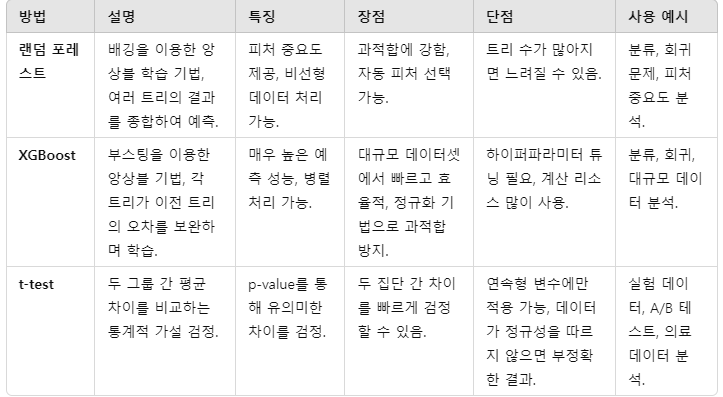

In [ ]:
data.shape


(20, 23419)

In [ ]:
X = data[data.columns[:-1]]
y = data['Type']


In [ ]:
X


,1_105,1_8274,1_8700,1_9102,1_9103,1_9206,1_9237,1_9246,1_9405,1_9597,...,X_1547633,X_1558813,Y_113065,Y_113075,Y_113148,Y_113215,Y_113325,Y_113326,Y_113334,Y_113335
0,1.000000,0.000000,0.033333,0.015942,0.000000,0.154762,0.000000,0.026087,0.009615,0.605263,...,0.259804,0.166667,0.900000,0.645455,0.857143,0.850000,0.692857,0.507003,0.547222,0.548641
1,0.857143,0.000000,0.000000,0.058824,0.000000,0.384615,0.000000,0.000000,0.011765,0.303030,...,0.100000,0.500000,0.800000,1.000000,0.772222,0.600000,0.480000,0.595098,0.439205,0.588848
2,0.833333,0.000000,0.000000,0.000000,0.041667,0.384615,0.000000,0.000000,0.000000,0.336538,...,0.000000,0.483135,0.812500,0.960000,0.897959,0.750000,0.750000,0.592157,0.554985,0.461310
3,0.861111,0.000000,0.000000,0.000000,0.000000,0.428571,0.000000,0.017391,0.000000,0.600000,...,0.293519,0.361111,0.937500,0.600000,0.500000,0.733333,0.533333,0.581232,0.366305,0.517476
4,0.785714,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.000000,0.555556,0.785985,0.933333,0.750000,0.800000,0.562500,0.666667,0.602306,0.502723
5,0.857143,0.000000,0.000000,0.058824,0.000000,0.384615,0.000000,0.000000,0.011765,0.303030,...,0.100000,0.500000,0.800000,1.000000,0.772222,0.600000,0.480000,0.595098,0.439205,0.588848
6,1.000000,0.000000,0.000000,0.022727,0.033333,0.062500,0.016667,0.000000,0.000000,0.250000,...,0.000000,0.000000,0.816319,0.716667,0.893750,0.771429,0.650000,0.567647,0.478838,0.643275
7,1.000000,0.000000,0.083333,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000,0.666667,...,0.759259,0.666667,0.700000,0.600000,0.638889,0.800000,0.640000,0.616667,0.392232,0.505847
8,0.666667,0.071429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.000000,0.428571,0.621528,0.791667,0.875000,0.777778,0.812500,0.706250,0.485714,0.513393
9,0.833333,0.000000,0.000000,0.000000,0.041667,0.384615,0.000000,0.000000,0.000000,0.336538,...,0.000000,0.483135,0.812500,0.960000,0.897959,0.750000,0.750000,0.592157,0.554985,0.461310


In [ ]:
y


0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
Name: Type, dtype: float64

### (RF!=0) AND (P-VALUE < 0.05)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from scipy import stats

## 랜덤포레스트
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X, y)
rf_importances = rf_clf.feature_importances_

rf_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'RandomForest': rf_importances
}).sort_values(by='RandomForest', ascending=False)

## T-TEST
t_test_resultss = {}
type_0 = X[y == 0]
type_1 = X[y == 1]

for column in X.columns:
    t_stat, p_val = stats.ttest_ind(type_0[column], type_1[column], equal_var=False)
    t_test_resultss[column] = p_val

t_test_df = pd.DataFrame({
    'Feature': list(t_test_resultss.keys()),
    'p_value': list(t_test_resultss.values())
}).sort_values(by='p_value')

# 조건 (랜덤!=0, p-value < 0.05)
rf_filtered_df = rf_importances_df[rf_importances_df['RandomForest'] != 0]
t_test_filtered_df = t_test_df[t_test_df['p_value'] < 0.05]

# 상위 100부터 1000까지 100단위로 공통 피처 추출 및 결과 출력
for top_n in range(100, 1100, 100):
    t_test_filtered_df = t_test_df.head(top_n)
    # 공통 피처 추출
    common_features = set(rf_filtered_df['Feature']).intersection(t_test_filtered_df['Feature'])
    common_features_df = pd.DataFrame({'Feature': list(common_features)})
    common_features_df = common_features_df.merge(rf_importances_df, on='Feature')
    common_features_df = common_features_df.merge(t_test_df, on='Feature')
    # 결과 출력
    print(f"\n--- Common Features (Top {top_n} T-test & RF Importance > 0) ---")
    print(common_features_df)
    print(f"Number of Common Features for Top {top_n}: {len(common_features_df)}")




In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy import stats

# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter to ensure convergence
log_reg.fit(X, y)

# Extract feature coefficients and calculate absolute values for feature importance
log_reg_importances = np.abs(log_reg.coef_[0])

# Create a DataFrame for Logistic Regression importances
log_reg_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'LogisticRegression': log_reg_importances
}).sort_values(by='LogisticRegression', ascending=False)

# T-Test
t_test_resultss = {}
type_0 = X[y == 0]
type_1 = X[y == 1]

for column in X.columns:
    t_stat, p_val = stats.ttest_ind(type_0[column], type_1[column], equal_var=False)
    t_test_resultss[column] = p_val

t_test_df = pd.DataFrame({
    'Feature': list(t_test_resultss.keys()),
    'p_value': list(t_test_resultss.values())
}).sort_values(by='p_value')

# Filtered Features (Logistic Regression != 0, p-value < 0.05)
log_reg_filtered_df = log_reg_importances_df[log_reg_importances_df['LogisticRegression'] != 0]
t_test_filtered_df = t_test_df[t_test_df['p_value'] < 0.05]

# Extract and print common features for ranges from Top 100 to 1000 (100-step intervals)
for top_n in range(100, 1100, 100):
    t_test_top_n_df = t_test_df.head(top_n)
    # Common features extraction
    common_features = set(log_reg_filtered_df['Feature']).intersection(t_test_top_n_df['Feature'])
    common_features_df = pd.DataFrame({'Feature': list(common_features)})
    common_features_df = common_features_df.merge(log_reg_importances_df, on='Feature')
    common_features_df = common_features_df.merge(t_test_df, on='Feature')
    # Display resultss
    print(f"\n--- Common Features (Top {top_n} T-test & Logistic Regression Importance > 0) ---")
    print(common_features_df)
    print(f"Number of Common Features for Top {top_n}: {len(common_features_df)}")




### (LR!=0) AND (P-VALUE < 0.05)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy import stats

# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter to ensure convergence
log_reg.fit(X, y)

# Extract feature coefficients and calculate absolute values for feature importance
log_reg_importances = np.abs(log_reg.coef_[0])

# Create a DataFrame for Logistic Regression importances
log_reg_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'LogisticRegression': log_reg_importances
}).sort_values(by='LogisticRegression', ascending=False)

# T-Test
t_test_resultss = {}
type_0 = X[y == 0]
type_1 = X[y == 1]

for column in X.columns:
    t_stat, p_val = stats.ttest_ind(type_0[column], type_1[column], equal_var=False)
    t_test_resultss[column] = p_val

t_test_df = pd.DataFrame({
    'Feature': list(t_test_resultss.keys()),
    'p_value': list(t_test_resultss.values())
}).sort_values(by='p_value')

# Filtered Features (Logistic Regression != 0, p-value < 0.05)
log_reg_filtered_df = log_reg_importances_df[log_reg_importances_df['LogisticRegression'] != 0]
t_test_filtered_df = t_test_df[t_test_df['p_value'] < 0.05]

# Extract and print common features for ranges from Top 100 to 1000 (100-step intervals)
for top_n in range(100, 1100, 100):
    t_test_top_n_df = t_test_df.head(top_n)
    log_reg_top_n_df = log_reg_importances_df.head(top_n)
    # Common features extraction
    common_features = set(t_test_top_n_df['Feature']).intersection(log_reg_top_n_df['Feature'])
    common_features_df = pd.DataFrame({'Feature': list(common_features)})
    common_features_df = common_features_df.merge(log_reg_importances_df, on='Feature')
    common_features_df = common_features_df.merge(t_test_df, on='Feature')
    # Display resultss
    print(f"\n--- Top {top_n} T-test & Logistic Regression ---")
    print(f"Logistic Regression (Top {top_n}):")
    print(log_reg_top_n_df)
    print(f"T-test (Top {top_n}):")
    print(t_test_top_n_df)
    print(f"\n--- Common Features (Top {top_n}) ---")
    print(common_features_df)
    print(f"Number of Common Features for Top {top_n}: {len(common_features_df)}")




In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy import stats

# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X, y)

# Feature importance from Logistic Regression
log_reg_importances = np.abs(log_reg.coef_[0])
log_reg_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'LogisticRegression': log_reg_importances
}).sort_values(by='LogisticRegression', ascending=False)

# T-Test
t_test_resultss = {}
type_0 = X[y == 0]
type_1 = X[y == 1]
for column in X.columns:
    t_stat, p_val = stats.ttest_ind(type_0[column], type_1[column], equal_var=False)
    t_test_resultss[column] = p_val

t_test_df = pd.DataFrame({
    'Feature': list(t_test_resultss.keys()),
    'p_value': list(t_test_resultss.values())
}).sort_values(by='p_value')

# Save filtered common features for each range
with pd.ExcelWriter('/ssd_data/Methylation/results/step02_DMR/common_features_analysis_v1.xlsx') as writer:
    for top_n in range(100, 1100, 100):
        # Top N from each method
        log_reg_top_n_df = log_reg_importances_df.head(top_n)
        t_test_top_n_df = t_test_df.head(top_n)
        # 조건 적용: LogisticRegression > 0, p-value < 0.05
        log_reg_filtered = log_reg_top_n_df[log_reg_top_n_df['LogisticRegression'] > 0]
        t_test_filtered = t_test_top_n_df[t_test_top_n_df['p_value'] < 0.05]
        # 공통 Feature 추출 (조건 만족한 것들 중에서)
        common_features_df = pd.merge(log_reg_filtered, t_test_filtered, on='Feature', how='inner')
        # 저장
        sheet_name = f'Top_{top_n}'
        common_features_df.to_excel(writer, sheet_name=sheet_name, index=False)
        # 출력 (optional)
        print(f"\n--- Top {top_n} ---")
        print(f"Number of Common Features (조건 만족): {len(common_features_df)}")
        print(common_features_df)

